# Trader Performance vs Market Sentiment Analysis

## Objective

The goal of this analysis is to understand how market sentiment (Fear vs Greed) influences trader performance. By combining trading data with sentiment indicators, we aim to identify patterns in profitability, win rates, and trading behavior that can help inform more effective trading strategies.

## Dataset Overview

- **Trader Data**: Contains trade-level information including execution price, size, side, and closed PnL  
- **Sentiment Data**: Bitcoin market sentiment classified as Fear, Greed, etc.  

Goal: Combine both datasets to analyze behavioral and performance trends.

##Dataset Loading

In [1]:
from google.colab import files

In [2]:
uploaded = files.upload()


Saving fear_greed_index.csv to fear_greed_index.csv
Saving historical_data.csv to historical_data.csv


In [54]:
import pandas as pd

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

trades.head(5)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [55]:
sentiment.head(5)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


##Initial Data Exploration

In [56]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [57]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [58]:
sentiment.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [59]:
trades.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


<Axes: >

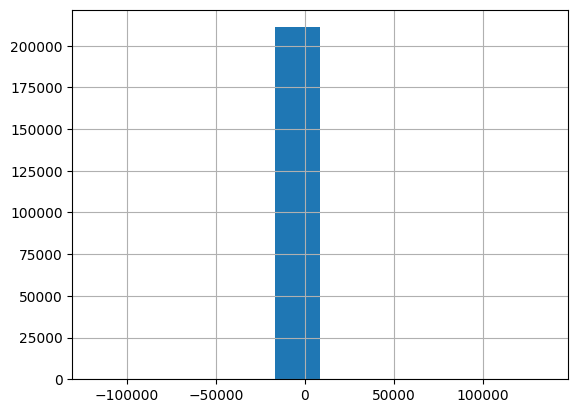

In [60]:
df_trades = trades.copy()
df_trades['Closed PnL'].hist()

##Data Pre-Processing

In [61]:
trades['date'] = pd.to_datetime(trades['Timestamp'], unit='ms').dt.strftime('%Y-%m-%d')
sentiment['date'] = pd.to_datetime(sentiment['timestamp'], unit='s').dt.strftime('%Y-%m-%d')

In [62]:
sentiment_dict = dict(zip(sentiment['date'], sentiment['classification']))

In [63]:
trades['sentiment'] = trades['date'].map(sentiment_dict)

In [64]:
trades = trades.dropna(subset=['sentiment', 'Closed PnL'])

##Exploratory Data Analysis

In [68]:
trades['win'] = trades['Closed PnL'] > 0
trades.groupby('sentiment')['win'].mean()

,win
sentiment,
Extreme Greed,0.490089
Fear,0.415146
Greed,0.446471
Neutral,0.317182


In [69]:
trades.groupby('sentiment')['Closed PnL'].mean()

,Closed PnL
sentiment,
Extreme Greed,25.418772
Fear,50.047622
Greed,87.894859
Neutral,22.229713


In [70]:
trades['sentiment'].value_counts(dropna=False)

,count
sentiment,
Fear,133871
Greed,36289
Neutral,7141
Extreme Greed,6962


###Average Profit by Market Sentiment

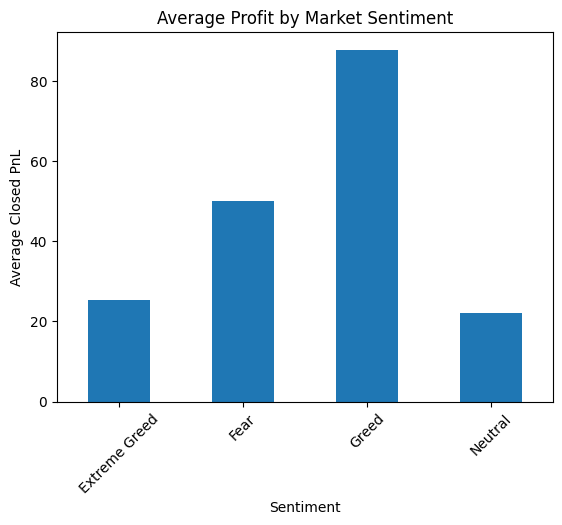

In [73]:
import matplotlib.pyplot as plt
trades.groupby('sentiment')['Closed PnL'].mean().plot(kind='bar')
plt.title('Average Profit by Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.xlabel('Sentiment')
plt.xticks(rotation=45)
plt.show()

The chart shows a clear variation in average profitability across different market sentiment phases. Profits are highest during Greed, indicating that traders generally perform better in bullish conditions. While Fear also shows moderate profitability, it is noticeably lower than Greed, suggesting that uncertainty may impact trade outcomes. Interestingly, Extreme Greed does not translate into higher profits, which could imply that traders tend to enter positions too late during overly optimistic market phases. Neutral conditions show the weakest performance, likely due to the absence of a strong directional trend.

###Win Rate by Market Sentiment

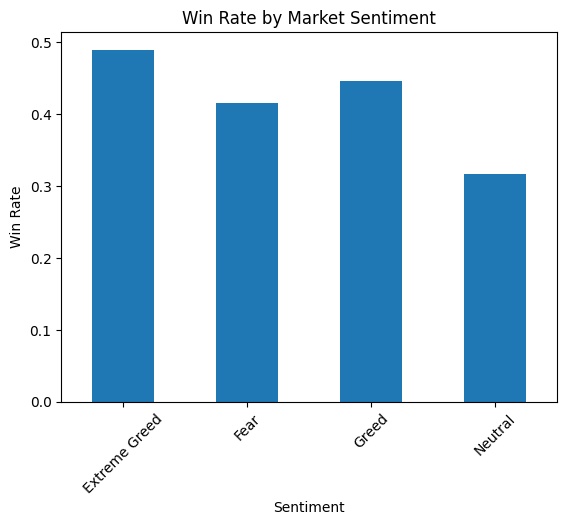

In [74]:
trades.groupby('sentiment')['win'].mean().plot(kind='bar')
plt.title('Win Rate by Market Sentiment')
plt.ylabel('Win Rate')
plt.xlabel('Sentiment')
plt.xticks(rotation=45)
plt.show()

The win rate also varies noticeably across different sentiment phases. Extreme Greed shows the highest win rate (49%), followed by Greed (44%) and Fear (41%), while Neutral conditions have the lowest (32%). This suggests that trades are more likely to be successful during bullish market conditions, where price movements are more predictable and trend-driven. In contrast, Neutral markets appear less favorable, likely due to the lack of clear direction. The relatively strong performance even during Fear indicates that opportunities still exist, but they are less consistent compared to Greed phases.

###Number of Trades by Sentiment

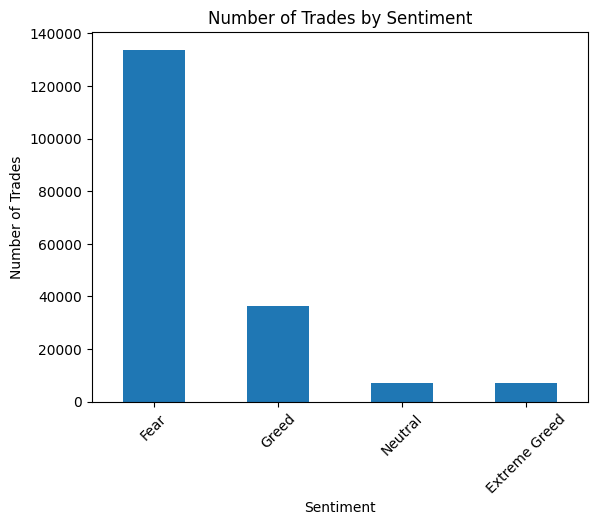

In [75]:
trades['sentiment'].value_counts().plot(kind='bar')
plt.title('Number of Trades by Sentiment')
plt.ylabel('Number of Trades')
plt.xlabel('Sentiment')
plt.xticks(rotation=45)
plt.show()

The distribution of trades across sentiment phases shows a clear imbalance, with Fear dominating trading activity by a large margin (approx. 133k trades) compared to other conditions. This indicates that traders are significantly more active during uncertain or declining market phases, possibly due to increased volatility or reactive decision-making. In contrast, Greed, Neutral, and Extreme Greed phases see much lower participation, suggesting that traders may be more selective or confident during stable or upward trends. Overall, this highlights that high activity does not necessarily correspond to better performance, as seen earlier where profitability was higher during Greed despite lower trade volume.

###Trade Count by Sentiment

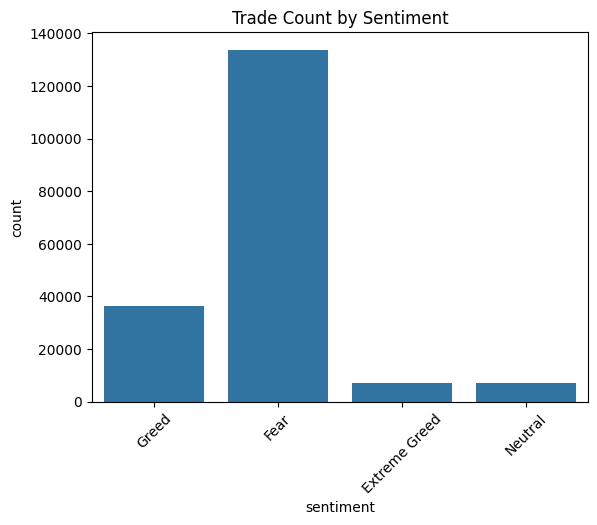

In [79]:
sns.countplot(x='sentiment', data=trades)
plt.title('Trade Count by Sentiment')
plt.xticks(rotation=45)
plt.show()

The trade count distribution shows a strong concentration of activity during Fear phases, which account for a significantly larger number of trades compared to all other sentiment categories. This suggests that traders are more active during uncertain or declining market conditions, likely driven by increased volatility and reactive decision-making.

In contrast, Greed phases show substantially lower trading volume, despite earlier observations of higher profitability and win rates. This indicates that traders may be more selective or confident in bullish conditions, executing fewer but more effective trades. Extreme Greed and Neutral phases exhibit the lowest activity, reflecting limited participation when the market is either overly optimistic or lacks clear direction.

Overall, this imbalance highlights an important pattern: higher trading activity does not necessarily lead to better performance, as the most active phase (Fear) does not correspond to the most profitable one (Greed).

###Correlation Heatmap of Trading Features

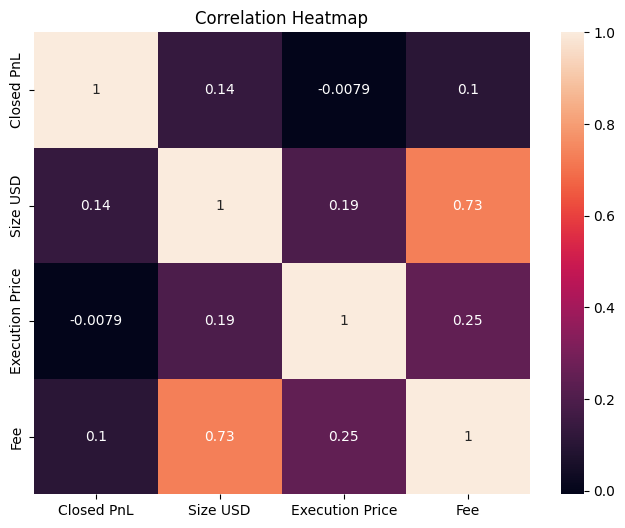

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(trades[['Closed PnL', 'Size USD', 'Execution Price', 'Fee']].corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap shows that most trading features have weak relationships with Closed PnL, indicating that profitability is not strongly driven by individual trade parameters alone. For instance, Size USD has only a slight positive correlation with PnL (approx. 0.14), suggesting that larger trades do not necessarily guarantee higher profits. Similarly, Execution Price shows almost no correlation with PnL, implying that entry price alone is not a strong predictor of success.

One notable observation is the strong correlation between Size USD and Fee (approx. 0.73), which is expected as larger trades incur higher transaction costs. However, since Fee itself has very little correlation with PnL, it suggests that transaction costs are not the primary factor affecting profitability.

Overall, these patterns indicate that market sentiment and broader conditions likely play a more significant role in influencing trading outcomes than individual trade-level variables, reinforcing the earlier findings from sentiment-based analysis.

###Boxplot of PnL Distribution by Sentiment

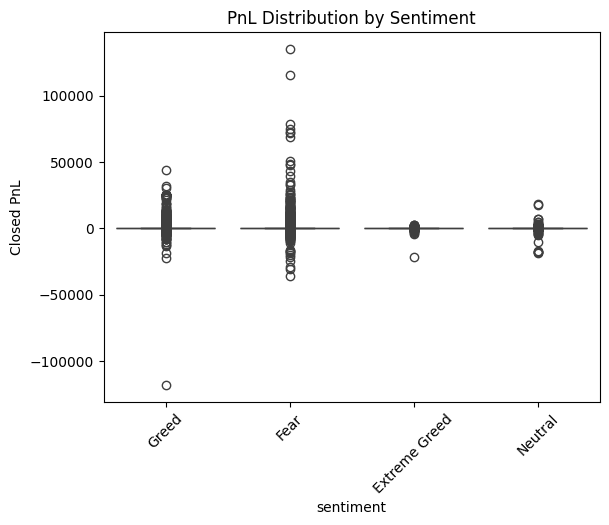

In [78]:
sns.boxplot(x='sentiment', y='Closed PnL', data=trades)
plt.title('PnL Distribution by Sentiment')
plt.xticks(rotation=45)
plt.show()

The boxplot provides a clearer view of the spread and variability in trading outcomes across different sentiment phases. Fear exhibits the widest range of PnL values, with both extreme gains and significant losses, along with several outliers on both ends. This indicates a highly volatile environment where outcomes are less predictable and risk is higher.

In contrast, Greed shows a relatively more concentrated distribution, with fewer extreme losses and a more balanced spread, suggesting more consistent performance. The presence of outliers in Greed still indicates opportunities for high returns, but overall variability is lower compared to Fear.

Extreme Greed and Neutral phases display much narrower ranges, with fewer outliers and lower overall variation, indicating limited trading opportunities and less dynamic market conditions. Additionally, the distributions appear slightly skewed, particularly in Fear, where large negative and positive outliers suggest uneven risk-reward scenarios.

Overall, the chart highlights that Fear is associated with high dispersion and risk, while Greed offers comparatively stable and more predictable trading outcomes.

## Strategic Insights

- Traders tend to achieve better profitability and win rates during **Greed phases**, suggesting that bullish market conditions are more favorable for trading. A more aggressive strategy may be beneficial during these periods.

- Despite high trading activity during **Fear phases**, performance is lower and more volatile. This indicates the need for stronger risk management and selective trading during uncertain market conditions.

- **Extreme Greed does not necessarily lead to higher profits**, which may suggest late entries or overconfidence. Traders should avoid overexposure during highly optimistic market phases.

- **Neutral market conditions show the weakest performance**, indicating that low-trend environments may not be ideal for active trading strategies.